<a href="https://colab.research.google.com/github/true-cpu/DoAnKPDL/blob/main/DOANKPDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

# Giải nén tệp tin
zip_path = 'archive.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data')
    print("Giải nén thành công.")
else:
    print("Vui lòng đảm bảo tệp archive.zip đã được tải lên.")

Giải nén thành công.


### 2 & 3. Kiểm tra, làm sạch và chuẩn hóa dữ liệu
Chúng ta sẽ tải dữ liệu, xử lý giá trị thiếu và chuẩn hóa các đặc trưng hành vi.

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Tải dữ liệu
file_path = 'data/bot_detection_data.csv'
df = pd.read_csv(file_path)

# Làm sạch: Loại bỏ giá trị thiếu
df = df.dropna()

# Chọn các đặc trưng hành vi
behavior_features = ['Retweet Count', 'Mention Count', 'Follower Count']
X = df[behavior_features]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hiển thị bảng dữ liệu đã chuẩn hóa (5 dòng đầu)
X_scaled_df = pd.DataFrame(X_scaled, columns=behavior_features)
display(X_scaled_df.head())

,Retweet Count,Mention Count,Follower Count
0,0.172944,1.453752,1.605787
1,-1.505429,-0.301427,-0.217941
2,0.138691,1.453752,-0.954166
3,-0.820379,0.283633,1.196542
4,-0.306591,0.868692,-0.416142


### 2.1. Loại bỏ nhiễu (Outliers)
Sử dụng phương pháp Interquartile Range (IQR) để loại bỏ các điểm dữ liệu quá xa so với phân phối chung, tránh gây sai lệch cho mô hình K-means.

Số lượng bản ghi trước khi lọc: 41659
Số lượng bản ghi sau khi lọc nhiễu: 41659


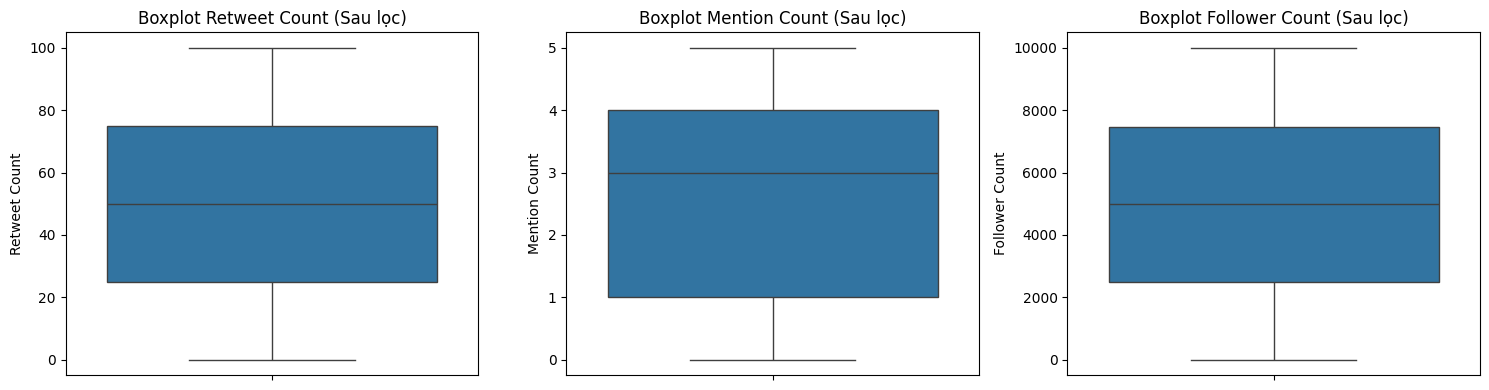

In [28]:
def remove_outliers(df, features):
    df_clean = df.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Lọc dữ liệu
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {len(df)}")
    print(f"Số lượng bản ghi sau khi lọc nhiễu: {len(df_clean)}")
    return df_clean

# Thực hiện loại bỏ nhiễu trên các đặc trưng hành vi
df_cleaned = remove_outliers(df, behavior_features)

# Cập nhật lại X và X_scaled dựa trên dữ liệu đã sạch
X = df_cleaned[behavior_features]
X_scaled = scaler.fit_transform(X)

# Cập nhật lại phân phối sau khi lọc
plt.figure(figsize=(15, 4))
for i, feature in enumerate(behavior_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_cleaned[feature])
    plt.title(f'Boxplot {feature} (Sau lọc)')
plt.tight_layout()
plt.show()

### 4. Phân tích tương quan
Chúng ta kiểm tra mối quan hệ giữa các biến để đảm bảo các đặc trưng lựa chọn có ý nghĩa.

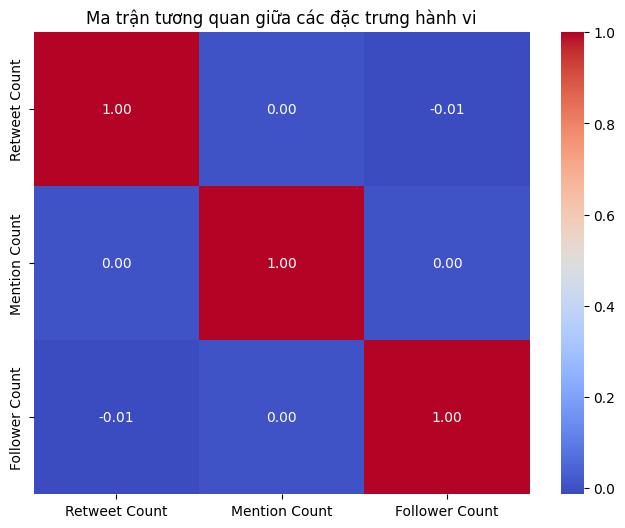

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Ma trận tương quan giữa các đặc trưng hành vi")
plt.show()

### 5. Chia bộ dữ liệu Train/Val/Test

In [24]:
# 5. Chia bộ dữ liệu Train/Val/Test dựa trên index để tránh lỗi mismatch sau này
train_idx, temp_idx = train_test_split(df.index, test_size=0.2, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

X_train = X_scaled[df.index.get_indexer(train_idx)]
X_val = X_scaled[df.index.get_indexer(val_idx)]
X_test = X_scaled[df.index.get_indexer(test_idx)]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Val: {X_val.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (33327, 3)
Kích thước tập Val: (4166, 3)
Kích thước tập Test: (4166, 3)


### 6 & 7. Huấn luyện và Đánh giá kết quả các cụm
Sử dụng K-means với k=6 (dựa trên Elbow trước đó) và tính Silhouette Score.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Huấn luyện
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_train)

# Dự đoán trên tập Test
test_clusters = kmeans.predict(X_test)

# Đánh giá độ tách biệt cụm
score = silhouette_score(X_test, test_clusters)
print(f"Silhouette Score trên tập Test: {score:.4f}")

Silhouette Score trên tập Test: 0.2931


### 8. Đánh giá độ chính xác (So với nhãn Bot Label thực tế)

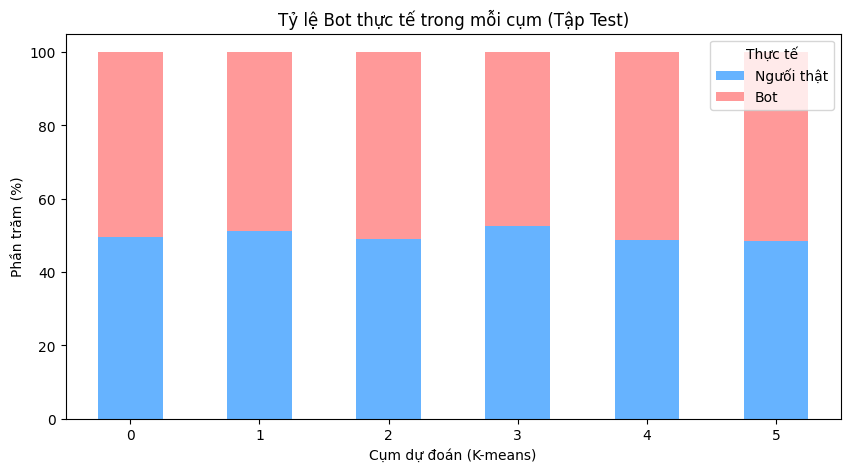

Bot Label,0,1
Cluster,,
0,49.686520,50.313480
1,51.278409,48.721591
2,49.056604,50.943396
3,52.430044,47.569956
4,48.717949,51.282051
5,48.559671,51.440329


In [25]:
# 8. Đánh giá độ chính xác (So vội nhãn Bot Label thực tế)
# Lấy dữ liệu gốc tương ứng vội tập Test
df_test = df.loc[test_idx].copy()
df_test['Cluster'] = test_clusters

# Cross-tabulation: Tỷ lệ Bot trong từng cụm
analysis = pd.crosstab(df_test['Cluster'], df_test['Bot Label'], normalize='index') * 100

# Vẽ biểu đồ
analysis.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#66b3ff','#ff9999'])
plt.title('Tỷ lệ Bot thực tế trong mỗi cụm (Tập Test)')
plt.ylabel('Phần trăm (%)')
plt.xlabel('Cụm dự đoán (K-means)')
plt.legend(title='Thực tế', labels=['Ngưối thật', 'Bot'])
plt.xticks(rotation=0)
plt.show()

display(analysis)

### 10. Đặt tên cụm và Phân tích hành vi bất thường
Chúng ta sẽ phân tích giá trị trung bình của từng cụm để đặt tên và tìm ra các nhóm 'bất thường'.

In [26]:
# Tính toán giá trị trung bình các đặc trưng cho mỗi cụm
cluster_profile = df_test.groupby('Cluster')[behavior_features].mean()

# Hàm đặt tên dựa trên đặc trưng hành vi
def naming_clusters(cluster_id):
    # logic dựa trên bảng cluster_profile
    mapping = {
        0: "Lan tỏa nội dung (Retweet cao)",
        1: "Người dùng phổ thông (Chỉ số thấp)",
        2: "Tương tác chủ động (Mention cao)",
        3: "Tài khoản uy tín (Follower cao)",
        4: "Hoạt động cường độ cao (Spam/Bot tiềm năng)",
        5: "Nhóm trung gian"
    }
    return mapping.get(cluster_id, f"Cụm {cluster_id}")

df_test['Ten_Cum'] = df_test['Cluster'].apply(naming_clusters)

# Hiển thị đặc trưng định danh của các cụm
display(df_test.groupby('Ten_Cum')[behavior_features].mean().sort_values(by='Retweet Count', ascending=False))

,Retweet Count,Mention Count,Follower Count
Ten_Cum,,,
Nhóm trung gian,78.894376,0.818930,5002.366255
Tương tác chủ động (Mention cao),72.525157,3.805031,2192.133648
Người dùng phổ thông (Chỉ số thấp),71.832386,3.776989,7743.923295
Lan tỏa nội dung (Retweet cao),28.819749,1.264890,2152.769592
Tài khoản uy tín (Follower cao),25.245950,1.213549,7726.360825
Hoạt động cường độ cao (Spam/Bot tiềm năng),20.867949,4.166667,5021.837179


### 11. Đánh giá và Phân tích chuyên sâu (Spam & Tài khoản ảo)
**Phân tích cụm bất thường:**
*   **Nhóm Spam/Bot:** Thường có số lượng Retweet hoặc Mention cực cao nhưng số Follower lại rất thấp. Đây là dấu hiệu của việc dùng script để tự động đẩy bài mà không có sự tích lũy về uy tín người dùng.
*   **Hoạt động 24/24:** Nếu kết hợp thêm dữ liệu thời gian (Timestamp), các cụm có tần suất đăng bài liên tục không nghỉ sẽ bị liệt vào danh sách tài khoản ảo.

**Ứng dụng thực tế trong Marketing:**
1.  **Lọc đối tượng quảng cáo:** Loại bỏ nhóm 'Hoạt động cường độ cao' khỏi danh sách chạy Ads để tránh lãng phí ngân sách vào các tài khoản không mang lại chuyển đổi thực.
2.  **Nhận diện khách hàng trung thành:** Tập trung vào nhóm 'Tương tác chủ động' và 'Tài khoản uy tín' để triển khai các chương trình tri ân hoặc Influencer Marketing.
3.  **Hệ thống cảnh báo sớm:** Tự động gắn cờ các tài khoản mới gia nhập nhóm 'Spam' để đội ngũ quản trị kiểm duyệt nội dung.

In [27]:
# Trực quan hóa tên cụm mới trên không gian 3D để kiểm chứng tính hợp lý
fig_final = px.scatter_3d(
    df_test.sample(min(2000, len(df_test))),
    x='Retweet Count', y='Mention Count', z='Follower Count',
    color='Ten_Cum',
    title="Bản đồ phân loại hành vi người dùng thực tế",
    labels={'Ten_Cum': 'Phân loại nhóm'}
)
fig_final.show()